# Getting Started

Sabi runs sequential active learning over Bayesian inverse problems: pick
where to evaluate the (expensive) target next, fit a surrogate, and use
the surrogate to estimate the posterior. This page walks through a
complete 2D run end to end on a curved target — no tempering, no
fancy emulator, no custom acquisition. Default everything.

## Install

Sabi uses [`uv`](https://docs.astral.sh/uv/) for dependency management:

```bash
uv sync --extra dev --extra probpipe --extra gpjax
```

The `probpipe` extra resolves a sibling clone of
[prob-pipe](https://github.com/arob5/prob-pipe); see the project README
for the expected layout. Run the test suite once to confirm the
environment is healthy:

```bash
uv run pytest
```

## 1. Setup

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from probpipe import unnormalized_log_prob

from sabi.acquisitions.ei import ExpectedImprovement
from sabi.algorithms import Algorithm, run
from sabi.emulators import TinyGPEmulator
from sabi.metrics.mmd import MMD
from sabi.problems.benchmarks import banana_2d

jax.config.update("jax_enable_x64", True)

## 2. The problem

`banana_2d()` returns a frozen `BenchmarkProblem` — fixed parameters,
validated reference distribution, ready to plug into the loop. Its
log-posterior has a curved ridge that's easy to visualize and just hard
enough that the active-learning story is interesting.

In [2]:
problem = banana_2d()
print(f"name:              {problem.name}")
print(f"input_shape:       {problem.input_shape}")
print(f"reference samples: {problem.reference_distribution.samples.shape}")

name:              banana_2d
input_shape:       (2,)
reference samples: (4096, 2)


## 3. The algorithm

`Algorithm` bundles every component the loop needs. Each field is
independently swappable — that's how ablations are expressed in sabi.
We use defaults: a `TinyGPEmulator` surrogate, `ExpectedImprovement`
for picking the next point, and the `MMD` metric scored against the
benchmark's reference samples.

In [3]:
algorithm = Algorithm(
    emulator_factory=lambda: TinyGPEmulator(input_shape=(2,)),
    acquisition=ExpectedImprovement(),
    n_initial=8,
    n_rounds=8,
    metrics=(MMD(n_estimate_samples=512, n_reference_samples=512),),
)

result = run(problem, algorithm, jax.random.key(0))

print("per-round MMD²:")
for i, row in enumerate(result.per_round_metrics):
    print(f"  round {i:2d}: {row.get('mmd2', float('nan')):.4f}")

per-round MMD²:
  round  0: 0.7140
  round  1: 0.5844
  round  2: 0.6005
  round  3: 0.6101
  round  4: 0.6268
  round  5: 0.5475
  round  6: 0.4177
  round  7: 0.4086


## 4. Results

Four panels:

1. **True target.** Log-posterior contours over the parameter box, with
   reference samples overlaid.
2. **Acquired points.** Same contours, with the initial design and the
   per-round acquisitions overlaid, colored by round.
3. **Surrogate posterior.** The expected log-posterior built from the
   final emulator predictive mean.
4. **Metric trajectory.** MMD² against the reference, by round.

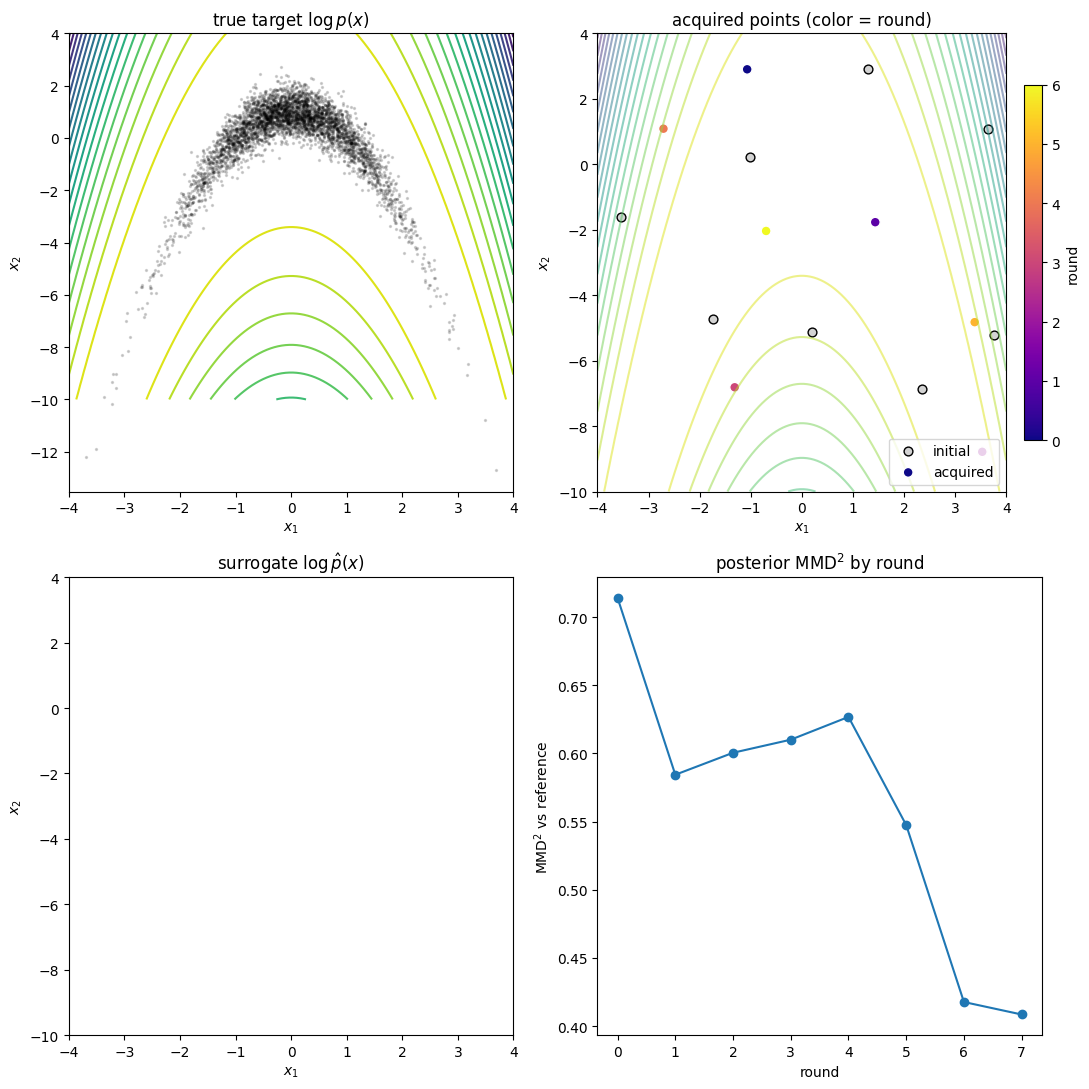

In [4]:
def grid_eval(fn, x_lo=-4.0, x_hi=4.0, y_lo=-10.0, y_hi=4.0, n=120):
    xs = jnp.linspace(x_lo, x_hi, n)
    ys = jnp.linspace(y_lo, y_hi, n)
    grid = jnp.stack(jnp.meshgrid(xs, ys, indexing="ij"), axis=-1).reshape(-1, 2)
    z = jnp.asarray(fn(grid)).reshape(n, n)
    return np.asarray(xs), np.asarray(ys), np.asarray(z)

xs, ys, log_p_true = grid_eval(problem.target_map)
_, _, log_p_hat = grid_eval(
    lambda g: unnormalized_log_prob(result.final_estimate, g)
)

ref = np.asarray(problem.reference_distribution.samples)
X = np.asarray(result.X)
X_init = X[: algorithm.n_initial]
X_acq = X[algorithm.n_initial :]
rounds_acq = np.arange(len(X_acq))

mmd_curve = [row.get("mmd2", float("nan")) for row in result.per_round_metrics]

fig, axes = plt.subplots(2, 2, figsize=(11, 11))

ax = axes[0, 0]
ax.contour(xs, ys, log_p_true.T, levels=20, cmap="viridis")
ax.scatter(ref[:, 0], ref[:, 1], s=2, alpha=0.15, color="black")
ax.set_title("true target $\\log p(x)$")

ax = axes[0, 1]
ax.contour(xs, ys, log_p_true.T, levels=20, cmap="viridis", alpha=0.5)
ax.scatter(X_init[:, 0], X_init[:, 1], s=40, c="lightgray",
           edgecolor="black", label="initial")
sc = ax.scatter(X_acq[:, 0], X_acq[:, 1], s=50, c=rounds_acq,
                cmap="plasma", edgecolor="white", label="acquired")
ax.legend(loc="lower right")
ax.set_title("acquired points (color = round)")
fig.colorbar(sc, ax=ax, label="round", fraction=0.04, pad=0.04)

ax = axes[1, 0]
ax.contour(xs, ys, log_p_hat.T, levels=20, cmap="viridis")
ax.set_title("surrogate $\\log \\hat p(x)$")

ax = axes[1, 1]
ax.plot(np.arange(len(mmd_curve)), mmd_curve, marker="o")
ax.set_xlabel("round")
ax.set_ylabel("MMD$^2$ vs reference")
ax.set_title("posterior MMD$^2$ by round")

for ax in axes.ravel()[:3]:
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")

plt.tight_layout()
plt.show()

## Where to next

- **Concepts.** Read [design](design.md) for the system architecture and
  [notation](notation.md) for the shape conventions used throughout sabi's
  docstrings.
- **Picking components.** [emulators](emulators.md) compares the
  available emulator backends; tutorials on acquisitions, tempering, and
  Hydra sweeps are on the roadmap.
- **API reference.** The auto-generated reference indexes every public
  symbol under `sabi.*`.